c:\Users\p4nge\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Hasil rekomendasi tip: 19.21%


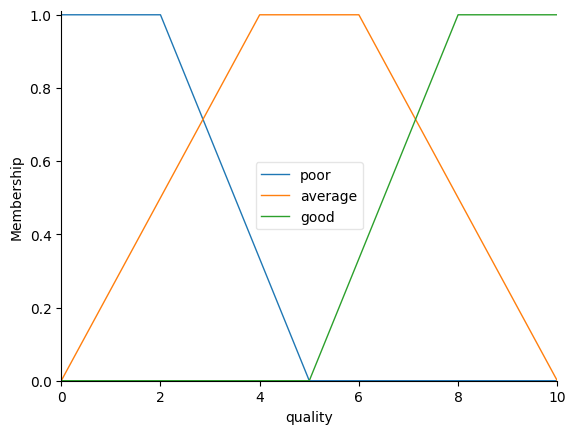

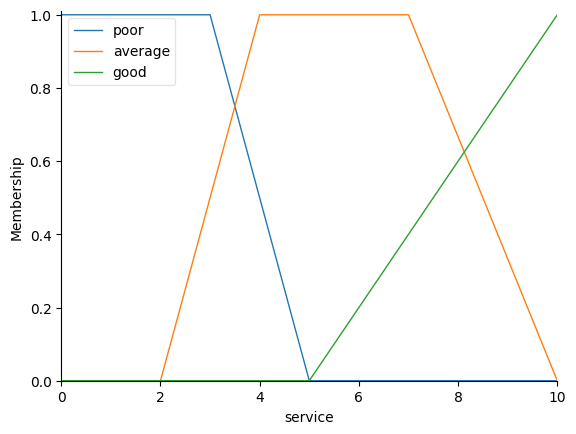

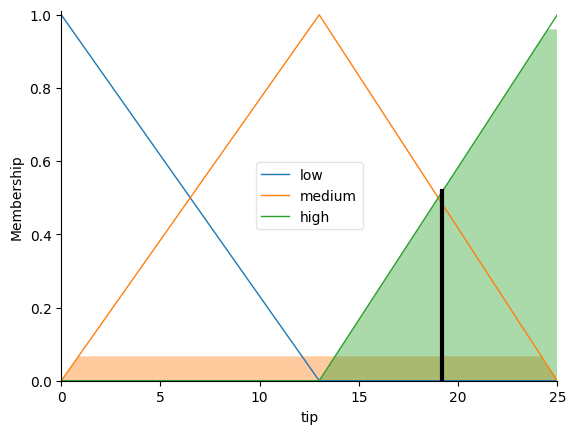

In [1]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# 1. Definisi Semesta Pembicaraan (Universe)
quality = ctrl.Antecedent(np.arange(0, 11, 1), 'quality')
service = ctrl.Antecedent(np.arange(0, 11, 1), 'service')
tip = ctrl.Consequent(np.arange(0, 26, 1), 'tip')

# 2. Implementasi Fungsi Keanggotaan Baru (Trapesium) - Gambar 22(a)
quality['poor'] = fuzz.trapmf(quality.universe, [0, 0, 2, 5])
quality['average'] = fuzz.trapmf(quality.universe, [0, 4, 6, 10])
quality['good'] = fuzz.trapmf(quality.universe, [5, 8, 10, 10])

# 3. Implementasi Fungsi Keanggotaan Baru (Trapesium) - Gambar 22(b)
service['poor'] = fuzz.trapmf(service.universe, [0, 0, 3, 5])
service['average'] = fuzz.trapmf(service.universe, [2, 4, 7, 10])
service['good'] = fuzz.trapmf(service.universe, [5, 10, 10, 10])

# 4. Fungsi Keanggotaan Output 'tip' (Menggunakan nilai dari study case 13.3)
tip['low'] = fuzz.trimf(tip.universe, [0, 0, 13])
tip['medium'] = fuzz.trimf(tip.universe, [0, 13, 25])
tip['high'] = fuzz.trimf(tip.universe, [13, 25, 25])


quality.view()  # Memunculkan grafik trapesium untuk variabel quality
service.view()  # Memunculkan grafik trapesium untuk variabel service
# =================================================================

# 5. Definisi Aturan Fuzzy (Aturan dari Study Case 13.3)
rule1 = ctrl.Rule(service['good'] | quality['good'], tip['high'])
rule2 = ctrl.Rule(service['average'], tip['medium'])
rule3 = ctrl.Rule(service['poor'] | quality['poor'], tip['low'])

# 6. Membuat Sistem Kontrol dan Simulasi
tipping_ctrl = ctrl.ControlSystem([rule1, rule2, rule3])
tipping_simulation = ctrl.ControlSystemSimulation(tipping_ctrl)

# 7. Memasukkan Nilai Input Uji Coba (Sesuai contoh kasus: quality = 6.5, service = 9.8)
tipping_simulation.input['quality'] = 6.5
tipping_simulation.input['service'] = 9.8

# 8. Melakukan Perhitungan Defuzzifikasi
tipping_simulation.compute()

# 9. Menampilkan Hasil Output Angka
print(f"Hasil rekomendasi tip: {tipping_simulation.output['tip']:.2f}%")

# 10. Visualisasi Grafik Hasil Akhir 
tip.view(sim=tipping_simulation)

# Perintah wajib untuk menampilkan semua jendela grafik di layar
plt.show()